**Imports**

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import time

from numba import cuda

**Check GPU**

In [3]:
from numba import cuda

print(cuda.is_available())

True


In [4]:
print(cuda.get_current_device())

<CUDA device 0 'Tesla T4'>


**Load One MRI Image**

In [5]:
import os

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
print(os.listdir('/content/drive/MyDrive/Dataset'))

['Tumor_Dataset.zip']


In [8]:
!unzip "/content/drive/MyDrive/Dataset/Tumor_Dataset.zip" -d "/content/tumor_dataset"

Archive:  /content/drive/MyDrive/Dataset/Tumor_Dataset.zip
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y1.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y10.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y100.JPG  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y101.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y102.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y103.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y104.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y105.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y106.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y107.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y108.jpg  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y109.JPG  
  inflating: /content/tumor_dataset/brain_tumor_dataset/Tumor/Y11.jp

In [9]:

dataset_path = "/content/tumor_dataset/brain_tumor_dataset"

healthy_path = os.path.join(dataset_path, "healthy")
tumor_path = os.path.join(dataset_path, "Tumor")

In [10]:
#verify the folders
print(os.listdir(dataset_path))

['Tumor', 'healthy']


In [11]:
#load 1 MRI image
# Load one tumor image

image_name = os.listdir(tumor_path)[0]

print("Image Name :", image_name)

image_path = os.path.join(tumor_path, image_name)

print("Image Path :", image_path)

Image Name : Y8.jpg
Image Path : /content/tumor_dataset/brain_tumor_dataset/Tumor/Y8.jpg


In [12]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

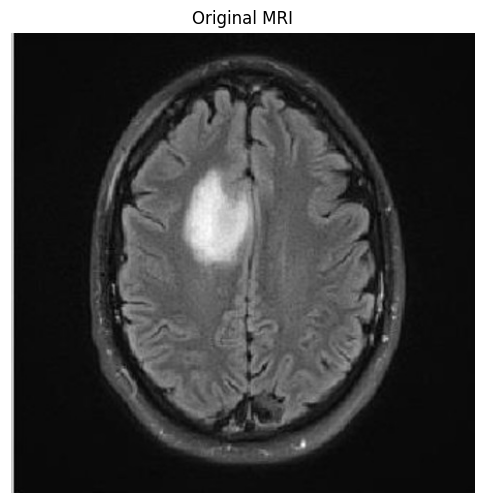

In [13]:
#display image
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title("Original MRI")

plt.axis("off")

plt.show()

In [14]:
#print image information
print("Shape :", img.shape)

print("Datatype :", img.dtype)

print("Minimum Pixel :", img.min())

print("Maximum Pixel :", img.max())

Shape : (446, 450, 3)
Datatype : uint8
Minimum Pixel : 0
Maximum Pixel : 255


**Normalisation->CPU implementation**

In [15]:
def normalize_cpu(image):
    """
    Normalize image pixels from [0,255] to [0,1]
    """

    normalized = image.astype(np.float32) / 255.0

    return normalized

In [16]:
normalized_img = normalize_cpu(img)

In [17]:
#verify
print("Original Image")

print("Datatype :", img.dtype)
print("Minimum :", img.min())
print("Maximum :", img.max())

print()

print("Normalized Image")

print("Datatype :", normalized_img.dtype)
print("Minimum :", normalized_img.min())
print("Maximum :", normalized_img.max())

Original Image
Datatype : uint8
Minimum : 0
Maximum : 255

Normalized Image
Datatype : float32
Minimum : 0.0
Maximum : 1.0


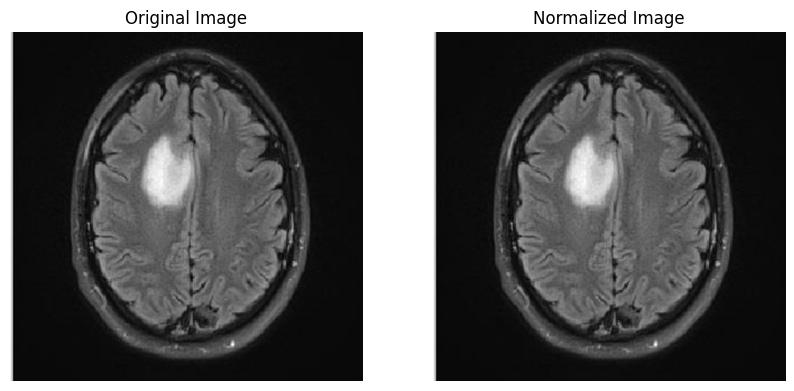

In [18]:
#display the images
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalized_img)
plt.title("Normalized Image")
plt.axis("off")

plt.show()

In [19]:
#CPU benchmark
start = time.perf_counter()

normalized_img = normalize_cpu(img)

end = time.perf_counter()

print(f"CPU Time : {(end-start)*1000:.6f} ms")

CPU Time : 1.144008 ms


**GPU Image normalisation**

Understanding the Kernel

In [20]:
from numba import cuda
import numpy as np

@cuda.jit
def normalize_kernel(input_img, output_img):

    # Get pixel coordinates handled by this thread
    row, col = cuda.grid(2)

    # Check whether the thread is inside image boundaries
    if row < input_img.shape[0] and col < input_img.shape[1]:

        # Normalize all three channels
        for c in range(input_img.shape[2]):
            output_img[row, col, c] = input_img[row, col, c] / 255.0

**Allocate GPU memory**

In [21]:
# Input image to GPU
d_input = cuda.to_device(img)

# Empty output image on GPU
d_output = cuda.device_array(img.shape, dtype=np.float32)

**Thread Configuration**

In [22]:
threads_per_block = (16,16)
blocks_per_grid_x = (img.shape[0] + threads_per_block[0] - 1) // threads_per_block[0]

blocks_per_grid_y = (img.shape[1] + threads_per_block[1] - 1) // threads_per_block[1]

blocks_per_grid = (blocks_per_grid_x,
                   blocks_per_grid_y)

**Launch Kernel**

In [23]:
normalize_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_output
)

**Copy Back**

In [24]:
gpu_result = d_output.copy_to_host()

In [25]:
print(gpu_result.min())

print(gpu_result.max())

0.0
1.0


**Display**

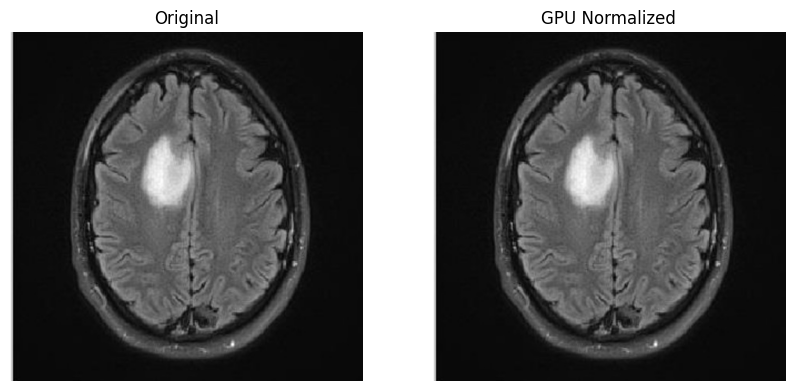

In [26]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gpu_result)
plt.title("GPU Normalized")
plt.axis("off")

plt.show()

In [27]:
print("Threads per block:", threads_per_block)
print("Blocks per grid:", blocks_per_grid)
print("Image size:", img.shape)

Threads per block: (16, 16)
Blocks per grid: (28, 29)
Image size: (446, 450, 3)


In [28]:
height, width, channels = img.shape

total_pixels = height * width

threads_per_block_total = (
    threads_per_block[0] *
    threads_per_block[1]
)

total_blocks = (
    blocks_per_grid[0] *
    blocks_per_grid[1]
)

total_threads = (
    total_blocks *
    threads_per_block_total
)

unused_threads = total_threads - total_pixels

print(f"Image Size           : {height} x {width}")
print(f"Total Pixels         : {total_pixels}")
print(f"Threads per Block    : {threads_per_block_total}")
print(f"Total Blocks         : {total_blocks}")
print(f"Total GPU Threads    : {total_threads}")
print(f"Unused Threads       : {unused_threads}")

Image Size           : 446 x 450
Total Pixels         : 200700
Threads per Block    : 256
Total Blocks         : 812
Total GPU Threads    : 207872
Unused Threads       : 7172


**CPU Thresholding**

In [29]:
def threshold_cpu(image, threshold=0.5):

    output = np.zeros_like(image)

    output[image > threshold] = 1.0

    return output

In [30]:
threshold_img = threshold_cpu(gpu_result)

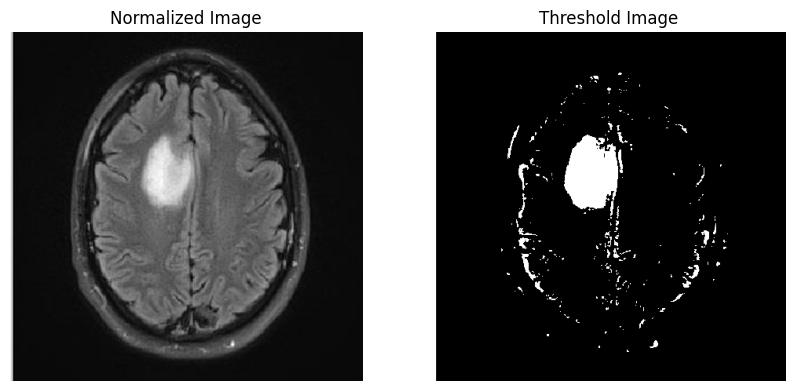

In [31]:
#display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gpu_result)
plt.title("Normalized Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(threshold_img)
plt.title("Threshold Image")
plt.axis("off")

plt.show()

**CPU benchmark**

In [32]:
start = time.perf_counter()

threshold_img = threshold_cpu(gpu_result)

end = time.perf_counter()

print(f"CPU Threshold Time : {(end-start)*1000:.6f} ms")

CPU Threshold Time : 2.113591 ms


**CUDA Thresholding Kernel**

In [33]:
@cuda.jit
def threshold_kernel(input_img, output_img, threshold):

    row, col = cuda.grid(2)

    if row < input_img.shape[0] and col < input_img.shape[1]:

        for c in range(input_img.shape[2]):

            if input_img[row, col, c] > threshold:
                output_img[row, col, c] = 1.0
            else:
                output_img[row, col, c] = 0.0

**Allocate GPU Memory**

In [34]:
d_input = cuda.to_device(gpu_result)

d_output = cuda.device_array(
    gpu_result.shape,
    dtype=np.float32
)

**Launch Kernel**

In [35]:
threads_per_block = (16,16)

blocks_per_grid_x = (
    gpu_result.shape[0] + threads_per_block[0] - 1
) // threads_per_block[0]

blocks_per_grid_y = (
    gpu_result.shape[1] + threads_per_block[1] - 1
) // threads_per_block[1]

blocks_per_grid = (
    blocks_per_grid_x,
    blocks_per_grid_y
)

In [36]:
#launch
threshold_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_output,
    0.5
)

**Copy Back**

In [37]:
gpu_threshold = d_output.copy_to_host()

**Display GPU Result**

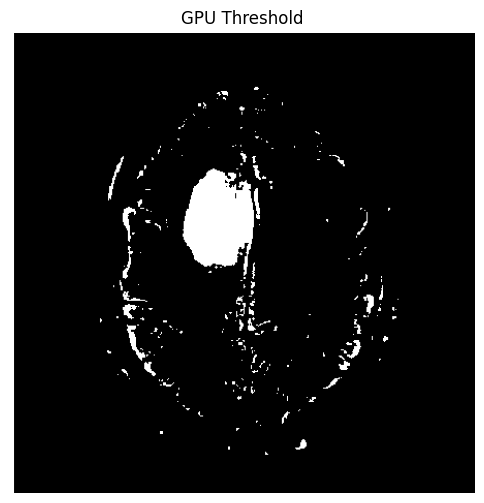

In [38]:
plt.figure(figsize=(6,6))

plt.imshow(gpu_threshold)

plt.title("GPU Threshold")

plt.axis("off")

plt.show()

**Verify**

In [39]:
print(gpu_threshold.min())
print(gpu_threshold.max())

0.0
1.0


**CPU vs GPU Benchmark**

In [40]:
# CPU
start = time.perf_counter()
threshold_cpu(gpu_result)
cpu_time = time.perf_counter() - start

# GPU
start = time.perf_counter()

threshold_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_output,
    0.5
)

cuda.synchronize()

gpu_time = time.perf_counter() - start

print(f"CPU Time : {cpu_time*1000:.6f} ms")
print(f"GPU Time : {gpu_time*1000:.6f} ms")
print(f"Speedup : {cpu_time/gpu_time:.2f}x")

CPU Time : 1.371931 ms
GPU Time : 1.319248 ms
Speedup : 1.04x


**Convert MRI to Grayscale**

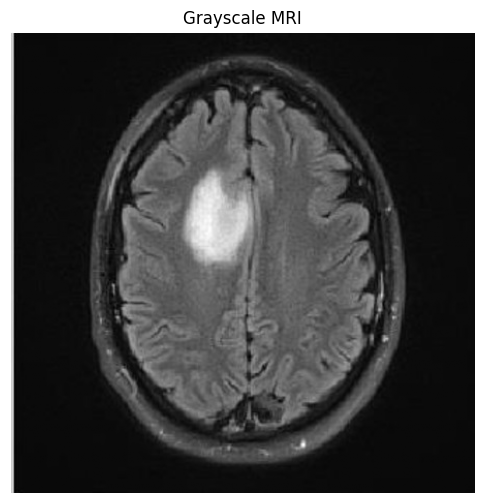

In [41]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray_img, cmap='gray')
plt.title("Grayscale MRI")
plt.axis("off")
plt.show()

In [42]:
print(gray_img.shape)
print(gray_img.dtype)

(446, 450)
uint8


**Filter**

In [43]:
kernel = np.array([
    [1,1,1],
    [1,1,1],
    [1,1,1]
], dtype=np.float32)

kernel = kernel / kernel.sum()

print(kernel)

[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


**CPU Function**

In [44]:
def convolution_cpu(image, kernel):

    height, width = image.shape

    output = np.zeros_like(image, dtype=np.float32)

    for row in range(1, height-1):

        for col in range(1, width-1):

            value = 0.0

            for i in range(-1,2):

                for j in range(-1,2):

                    value += (
                        image[row+i, col+j] *
                        kernel[i+1, j+1]
                    )

            output[row,col] = value

    return output

In [45]:
cpu_conv = convolution_cpu(gray_img, kernel)

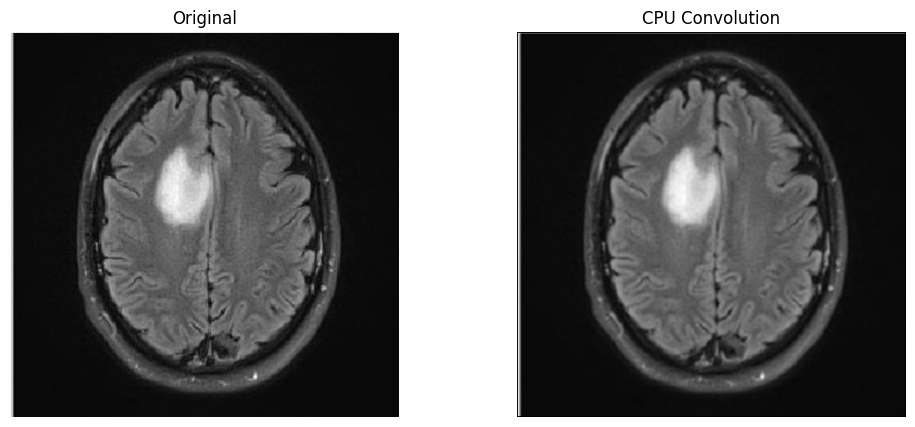

In [46]:
#display
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(gray_img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cpu_conv, cmap='gray')
plt.title("CPU Convolution")
plt.axis("off")

plt.show()

**Benchmark**

In [47]:
start = time.perf_counter()

cpu_conv = convolution_cpu(gray_img, kernel)

end = time.perf_counter()

print(f"CPU Convolution Time : {(end-start)*1000:.3f} ms")

CPU Convolution Time : 2177.974 ms


**Naive CUDA Convolution**

In [48]:
@cuda.jit
def convolution_kernel(input_img, kernel, output_img):

    row, col = cuda.grid(2)

    height = input_img.shape[0]
    width = input_img.shape[1]

    # Ignore image borders
    if row >= 1 and row < height-1 and col >= 1 and col < width-1:

        value = 0.0

        for i in range(-1, 2):

            for j in range(-1, 2):

                value += (
                    input_img[row+i, col+j] *
                    kernel[i+1, j+1]
                )

        output_img[row, col] = value

**Move data to GPU.**

In [49]:
d_input = cuda.to_device(gray_img.astype(np.float32))

d_kernel = cuda.to_device(kernel)

d_output = cuda.device_array(
    gray_img.shape,
    dtype=np.float32
)

**Thread Configuration**

In [50]:
threads_per_block = (16,16)

blocks_per_grid_x = (
    gray_img.shape[0] + threads_per_block[0]-1
)//threads_per_block[0]

blocks_per_grid_y = (
    gray_img.shape[1] + threads_per_block[1]-1
)//threads_per_block[1]

blocks_per_grid = (
    blocks_per_grid_x,
    blocks_per_grid_y
)

**Launch Kernel**

In [51]:
convolution_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_kernel,
    d_output
)

**Wait for GPU**

In [52]:
cuda.synchronize()

**Copy Back**

In [53]:
gpu_conv = d_output.copy_to_host()

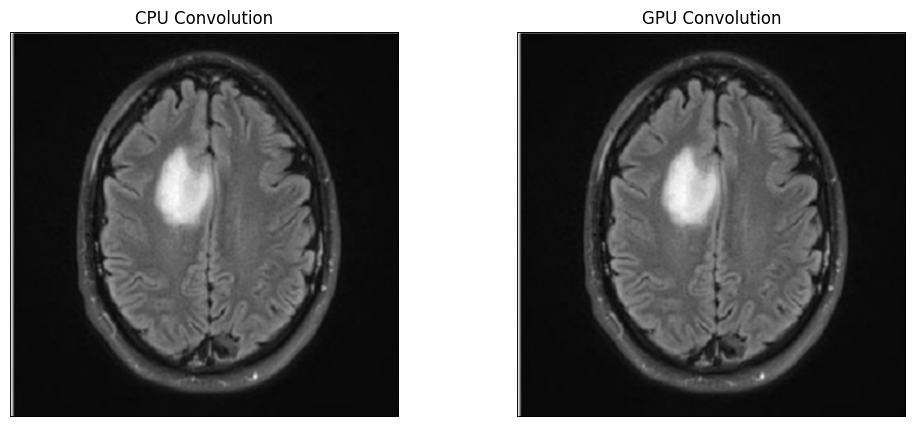

In [54]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cpu_conv, cmap="gray")
plt.title("CPU Convolution")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gpu_conv, cmap="gray")
plt.title("GPU Convolution")
plt.axis("off")

plt.show()

**Benchmark**

In [55]:
start = time.perf_counter()

convolution_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_kernel,
    d_output
)

cuda.synchronize()


In [56]:
#CPU timing
start_cpu = time.perf_counter()

cpu_conv = convolution_cpu(gray_img, kernel)

end_cpu = time.perf_counter()

cpu_time = end_cpu - start_cpu

In [57]:
#GPU Timing
start_gpu = time.perf_counter()

convolution_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_kernel,
    d_output
)

cuda.synchronize()

end_gpu = time.perf_counter()

gpu_time = end_gpu - start_gpu

In [58]:
print(f"CPU Convolution Time : {cpu_time*1000:.3f} ms")
print(f"GPU Convolution Time : {gpu_time*1000:.3f} ms")
print(f"Speedup : {cpu_time/gpu_time:.2f}x")

CPU Convolution Time : 1137.668 ms
GPU Convolution Time : 0.763 ms
Speedup : 1491.77x


**Shared Memory CUDA Convolution**

In [59]:
from numba import cuda, float32

TILE_SIZE = 16

In [60]:
#shared memory kernel
@cuda.jit
def shared_convolution_kernel(input_img, kernel, output_img):

    # Shared memory tile (16x16 tile + 1-pixel halo on each side)
    shared = cuda.shared.array((18, 18), dtype=float32)

    # Thread indices inside the block
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    # Global image coordinates
    row = cuda.blockIdx.x * cuda.blockDim.x + tx
    col = cuda.blockIdx.y * cuda.blockDim.y + ty

    # Shared memory coordinates
    s_row = tx + 1
    s_col = ty + 1

    height = input_img.shape[0]
    width = input_img.shape[1]

    # -------------------------------
    # Load center pixel
    # -------------------------------

    if row < height and col < width:
        shared[s_row, s_col] = input_img[row, col]
    else:
        shared[s_row, s_col] = 0.0

    # -------------------------------
    # Load left halo
    # -------------------------------

    if tx == 0:
        if row > 0 and col >= 1:
            shared[0, s_col] = input_img[row-1, col]

    # -------------------------------
    # Load right halo
    # -------------------------------

    if tx == TILE_SIZE-1:
        if row < height-1 and col < width:
            shared[17, s_col] = input_img[row+1, col]

    # -------------------------------
    # Load top halo
    # -------------------------------

    if ty == 0:
        if row < height and col > 0:
            shared[s_row, 0] = input_img[row, col-1]

    # -------------------------------
    # Load bottom halo
    # -------------------------------

    if ty == TILE_SIZE-1:
        if row < height and col < width-1:
            shared[s_row, 17] = input_img[row, col+1]

    # Wait until all threads finish loading

    cuda.syncthreads()

    # -------------------------------
    # Convolution
    # -------------------------------

    if row >= 1 and row < height-1 and col >= 1 and col < width-1:

        value = 0.0

        for i in range(-1,2):
            for j in range(-1,2):

                value += (
                    shared[s_row+i, s_col+j] *
                    kernel[i+1,j+1]
                )

        output_img[row,col] = value

**GPU Memory**

In [61]:
d_input = cuda.to_device(gray_img.astype(np.float32))

d_kernel = cuda.to_device(kernel)

d_output = cuda.device_array(
    gray_img.shape,
    dtype=np.float32
)

**Thread Configuration**

In [62]:
threads_per_block = (16,16)

blocks_per_grid_x = (
    gray_img.shape[0] + threads_per_block[0]-1
)//threads_per_block[0]

blocks_per_grid_y = (
    gray_img.shape[1] + threads_per_block[1]-1
)//threads_per_block[1]

blocks_per_grid = (
    blocks_per_grid_x,
    blocks_per_grid_y
)

**Launch kernel**

In [63]:
start = time.perf_counter()

shared_convolution_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_kernel,
    d_output
)

cuda.synchronize()

end = time.perf_counter()

shared_time = end-start

**Copy Result**

In [64]:
shared_output = d_output.copy_to_host()

**Display**

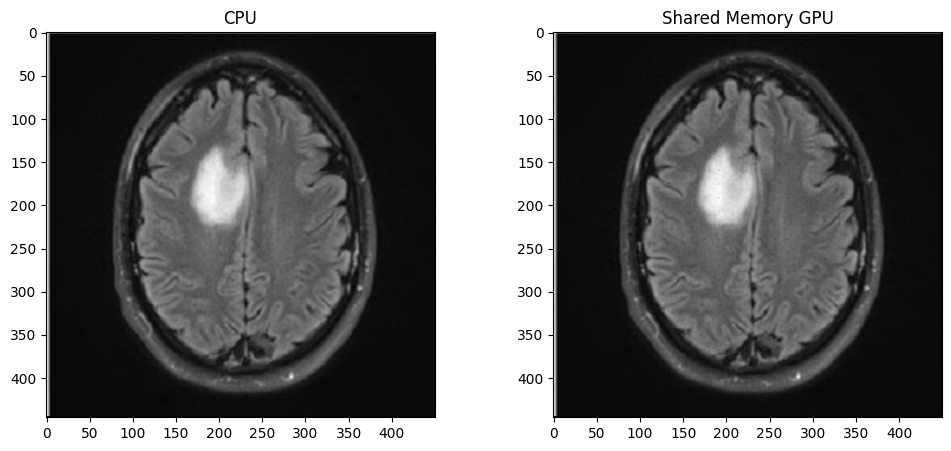

In [65]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cpu_conv,cmap='gray')
plt.title("CPU")

plt.subplot(1,2,2)
plt.imshow(shared_output,cmap='gray')
plt.title("Shared Memory GPU")

plt.show()

# ==========================================
#Benchmark on Original MRI Image
# ==========================================

In [66]:
print(f"CPU Time              : {cpu_time*1000:.3f} ms")
print(f"Naive GPU Time        : {gpu_time*1000:.3f} ms")
print(f"Shared GPU Time       : {shared_time*1000:.3f} ms")

print()

print(f"Naive Speedup         : {cpu_time/gpu_time:.2f}x")
print(f"Shared Speedup        : {cpu_time/shared_time:.2f}x")

CPU Time              : 1137.668 ms
Naive GPU Time        : 0.763 ms
Shared GPU Time       : 296.752 ms

Naive Speedup         : 1491.77x
Shared Speedup        : 3.83x


# ==========================================
# Benchmark on Large Image
# ==========================================

Create a Larger Image

In [67]:
# Create a large image by repeating the MRI

large_img = np.tile(gray_img, (8, 8))

print("Original :", gray_img.shape)
print("Large    :", large_img.shape)

Original : (446, 450)
Large    : (3568, 3600)


Allocate GPU Memory

In [68]:
d_input = cuda.to_device(large_img.astype(np.float32))

d_kernel = cuda.to_device(kernel)

d_output = cuda.device_array(
    large_img.shape,
    dtype=np.float32
)

**Grid Configuration**

In [69]:
threads_per_block = (16,16)

blocks_per_grid_x = (
    large_img.shape[0] + threads_per_block[0] - 1
) // threads_per_block[0]

blocks_per_grid_y = (
    large_img.shape[1] + threads_per_block[1] - 1
) // threads_per_block[1]

blocks_per_grid = (
    blocks_per_grid_x,
    blocks_per_grid_y
)

print("Blocks:", blocks_per_grid)

Blocks: (223, 225)


Warm-up

In [70]:
# Naive kernel warm-up
convolution_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_kernel,
    d_output
)

cuda.synchronize()

# Shared kernel warm-up
shared_convolution_kernel[
    blocks_per_grid,
    threads_per_block
](
    d_input,
    d_kernel,
    d_output
)

cuda.synchronize()

CPU Benchmark

In [71]:
# ==========================================
# CPU Benchmark
# ==========================================

ITER_CPU = 5

start = time.perf_counter()

for _ in range(ITER_CPU):
    cpu_conv = convolution_cpu(large_img, kernel)

end = time.perf_counter()

cpu_time = (end - start) / ITER_CPU

Naive GPU Benchmark

In [72]:
# ==========================================
# Naive GPU Benchmark
# ==========================================

ITER_GPU = 20

start = time.perf_counter()

for _ in range(ITER_GPU):

    convolution_kernel[
        blocks_per_grid,
        threads_per_block
    ](
        d_input,
        d_kernel,
        d_output
    )

cuda.synchronize()

end = time.perf_counter()

gpu_time = (end - start) / ITER_GPU

Shared Memory GPU Benchmark

In [73]:
# ==========================================
# Shared Memory GPU Benchmark
# ==========================================

ITER_GPU = 20

start = time.perf_counter()

for _ in range(ITER_GPU):

    shared_convolution_kernel[
        blocks_per_grid,
        threads_per_block
    ](
        d_input,
        d_kernel,
        d_output
    )

cuda.synchronize()

end = time.perf_counter()

shared_time = (end - start) / ITER_GPU

Performance Comparison

In [74]:
# ==========================================
# Performance Comparison
# ==========================================

print("="*55)
print("        PERFORMANCE COMPARISON")
print("="*55)

print(f"Image Size              : {large_img.shape}")

print()

print(f"CPU Time               : {cpu_time*1000:.3f} ms")
print(f"Naive GPU Time         : {gpu_time*1000:.3f} ms")
print(f"Shared GPU Time        : {shared_time*1000:.3f} ms")

print()

print(f"Naive GPU Speedup      : {cpu_time/gpu_time:.2f}x")
print(f"Shared GPU Speedup     : {cpu_time/shared_time:.2f}x")

        PERFORMANCE COMPARISON
Image Size              : (3568, 3600)

CPU Time               : 88022.492 ms
Naive GPU Time         : 5.993 ms
Shared GPU Time        : 5.944 ms

Naive GPU Speedup      : 14688.77x
Shared GPU Speedup     : 14808.96x


Graph 1: Execution Time Comparison

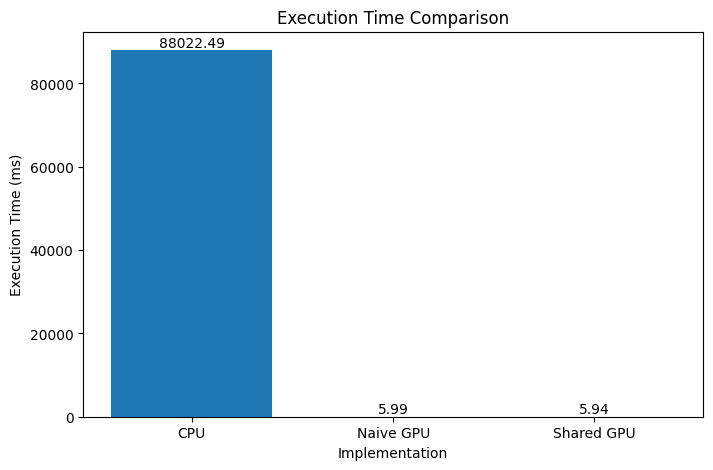

In [75]:
import matplotlib.pyplot as plt

methods = ["CPU", "Naive GPU", "Shared GPU"]

times = [
    cpu_time * 1000,
    gpu_time * 1000,
    shared_time * 1000
]

plt.figure(figsize=(8,5))

plt.bar(methods, times)

plt.title("Execution Time Comparison")

plt.xlabel("Implementation")

plt.ylabel("Execution Time (ms)")

for i, value in enumerate(times):
    plt.text(i, value, f"{value:.2f}", ha='center', va='bottom')

plt.show()

**Graph 2: Speedup Comparison**

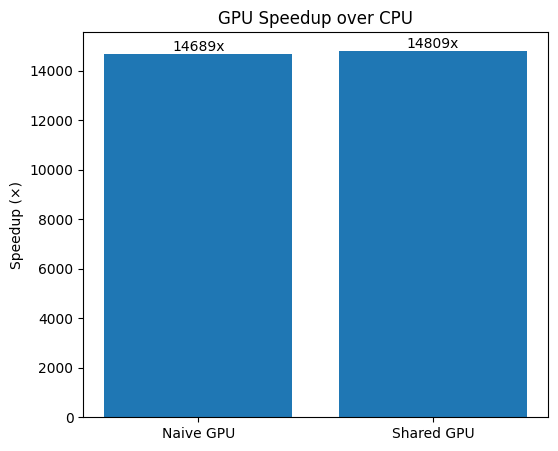

In [76]:
speedups = [
    cpu_time/gpu_time,
    cpu_time/shared_time
]

labels = [
    "Naive GPU",
    "Shared GPU"
]

plt.figure(figsize=(6,5))

plt.bar(labels, speedups)

plt.title("GPU Speedup over CPU")

plt.ylabel("Speedup (×)")

for i, value in enumerate(speedups):
    plt.text(i, value, f"{value:.0f}x", ha='center', va='bottom')

plt.show()

Graph 3

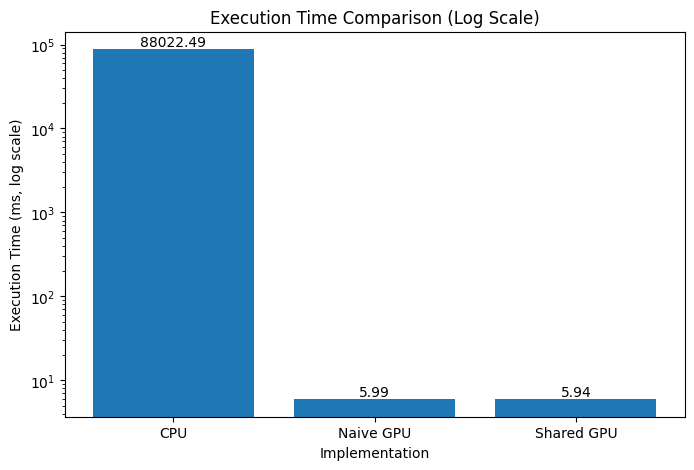

In [77]:
plt.figure(figsize=(8,5))

plt.bar(methods, times)

plt.yscale("log")

plt.title("Execution Time Comparison (Log Scale)")

plt.xlabel("Implementation")

plt.ylabel("Execution Time (ms, log scale)")

for i, value in enumerate(times):
    plt.text(i, value, f"{value:.2f}", ha='center', va='bottom')

plt.show()